# Day 125 — Stacking & Blending Ensembles
**Month 7 | Week 2 | Day 1 | Advanced ML**

---
| | |
|---|---|
| **Dataset** | RetailPulse India — Customer Churn (500 rows, seed=121) |
| **Tools** | scikit-learn, xgboost, lightgbm, pandas, matplotlib |
| **Max Score** | 80 pts + 10★ bonus |
| **GitHub** | Month7-AdvancedML-Portfolio |

---
> **Rule:** Write your goal + method in plain English as a comment before each code block.  
> Complete every task before opening Section 4 (Answer Key).

---
## Section 1 — Raw Data


In [1]:
# Section 1: Raw Data — DO NOT MODIFY THIS CELL
# Goal: Generate RetailPulse India churn dataset (same seed=121 used across Month 7)

import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

regions      = ["North", "South", "East", "West", "Central"]
categories   = ["Electronics", "Clothing", "Grocery", "Furniture", "Sports"]
segments     = ["Budget", "Standard", "Mid-Value", "Premium"]
payment_mode = ["UPI", "Credit Card", "Debit Card", "Cash on Delivery", "EMI"]

df_raw = pd.DataFrame({
    "customer_id":       [f"CUST{str(i).zfill(4)}" for i in range(1, n+1)],
    "age":               np.random.randint(22, 65, n),
    "tenure_months":     np.random.randint(1, 60, n),
    "monthly_spend":     np.round(np.random.exponential(3500, n) + 800, 2),
    "num_orders":        np.random.randint(1, 40, n),
    "return_rate":       np.round(np.random.beta(2, 8, n), 3),
    "support_tickets":   np.random.randint(0, 10, n),
    "region":            np.random.choice(regions, n),
    "top_category":      np.random.choice(categories, n),
    "customer_segment":  np.random.choice(segments, n),
    "payment_mode":      np.random.choice(payment_mode, n),
    "last_login_days":   np.random.randint(1, 180, n),
    "discount_used":     np.random.randint(0, 15, n),
    "loyalty_score":     np.round(np.random.uniform(1, 10, n), 1),
})

# Churn label — logistic signal
churn_score = (
    -0.04 * df_raw["tenure_months"]
    + 0.0001 * df_raw["monthly_spend"]
    + 0.3  * df_raw["return_rate"] * 10
    + 0.15 * df_raw["support_tickets"]
    + 0.01 * df_raw["last_login_days"]
    - 0.05 * df_raw["loyalty_score"]
    + np.random.normal(0, 1, n)
)
df_raw["churned"] = (churn_score > churn_score.median()).astype(int)

print(f"Dataset shape:  {df_raw.shape}")
print(f"Churn rate:     {df_raw['churned'].mean():.2%}")
print(f"Columns:        {list(df_raw.columns)}")
print()
print(df_raw.head(5).to_string(index=False))


Dataset shape:  (500, 15)
Churn rate:     50.00%
Columns:        ['customer_id', 'age', 'tenure_months', 'monthly_spend', 'num_orders', 'return_rate', 'support_tickets', 'region', 'top_category', 'customer_segment', 'payment_mode', 'last_login_days', 'discount_used', 'loyalty_score', 'churned']

customer_id  age  tenure_months  monthly_spend  num_orders  return_rate  support_tickets  region top_category customer_segment payment_mode  last_login_days  discount_used  loyalty_score  churned
   CUST0001   24             36        8705.77          14        0.091                2 Central       Sports         Standard          EMI               84             11            7.1        1
   CUST0002   43             24        2269.58          19        0.149                2   South  Electronics          Premium          UPI                7              7            7.9        0
   CUST0003   30             16        4257.86          13        0.216                8   South     Clothing      

---
## Section 2 — Concept Notes: Stacking & Blending Ensembles

### The Core Problem Ensembles Solve
Any single model has a **bias-variance tradeoff**. Stacking exploits the fact that  
different models make **different errors** — by combining them intelligently, you  
cancel out individual weaknesses.

---
### Three Ensemble Strategies

| Strategy | How It Works | When To Use |
|---|---|---|
| **Voting** | Average (soft) or majority (hard) predictions from N models | Quick wins; interpretable; no extra training |
| **Blending** | Train base models on train set → predict on a held-out val set → train meta-learner on those predictions | Simple; less data leakage risk; faster to build |
| **Stacking** | Train base models with cross-validation → generate out-of-fold predictions → train meta-learner | More data-efficient; usually higher performance |

---
### Stacking Architecture (2-Level)

```
LEVEL 0 (Base Models)          LEVEL 1 (Meta-Learner)
────────────────────           ──────────────────────
XGBoost       ─┐
LightGBM      ─┼──→ OOF predictions (new feature matrix) ──→ Logistic Regression
Random Forest  ─┤                                              (makes final call)
Logistic Reg  ─┘
```

- **OOF = Out-Of-Fold**: for each fold in CV, base models predict on the held-out fold.
  After all folds, every training row has exactly one OOF prediction → no leakage.
- The meta-learner trains on these OOF predictions as its input features.

---
### Blending Architecture

```
Train set ──70%──→ Base models (fit here)
          └─30%──→ Holdout set → base models predict → meta-learner trains here
Test set  ────────→ Base models predict → meta-learner predicts (final output)
```
Blending is simpler but wastes 30% of training data for the meta-learner.

---
### Key Hyperparameters

| Param | Applies To | Effect |
|---|---|---|
| `cv` in StackingClassifier | Stacking | More folds = better OOF quality; slower |
| `stack_method` | Stacking | `predict_proba` gives soft predictions (preferred for classification) |
| `passthrough=True` | Stacking | Passes original features to meta-learner too (often helps) |
| `final_estimator` | Stacking | The meta-learner; LogisticRegression is default and usually best |
| Voting `weights` | Voting | Assign higher trust to stronger models |

---
### What the Meta-Learner Actually Learns
> "When XGBoost says 0.8 and LightGBM says 0.3 but Random Forest says 0.7,  
> the true label is usually 1."

The meta-learner learns the **reliability pattern** of each base model —  
essentially, how to trust them conditionally.

---
### Real-World Use
- **Kaggle competitions:** Stacking is responsible for most winning solutions.
- **Fraud detection:** Stacking heterogeneous models (tree + linear + neural) to catch different fraud patterns.
- **Credit scoring:** Blending with regulatory-approved base models; meta-learner provides the final score.
- **Limitation:** Complexity ↑, inference latency ↑, interpretability ↓. In production, a well-tuned single model often matches stacking.

---
### Interview Framing
> *"Stacking doesn't improve any individual model — it builds a second model  
> that learns when each base model is trustworthy. The key discipline is preventing  
> data leakage: the meta-learner must never see predictions made on data the base  
> models trained on — that's why we use out-of-fold predictions, not in-sample predictions."*


---
## Section 3 — Practice Guide

**Scenario:**  
RetailPulse India's ML team ran individual models (XGBoost, LightGBM, CatBoost) in Week 1.  
The CAO now asks: *"Can we squeeze more performance by combining them?  
Show me stacking vs blending vs voting — and tell me whether the complexity is worth it."*

Complete all tasks before opening Section 4.

---
### Task 1 — Data Preparation (10 pts)

**Objective:** Prepare the feature matrix for ensemble training.

**Steps:**
1. Load `df_raw` (from Section 1 — already generated)
2. One-hot encode: `region`, `top_category`, `customer_segment`, `payment_mode`
3. Drop `customer_id`
4. Split: `X` (all features), `y` (`churned`)
5. Train-test split: 80/20, `random_state=121`, stratified
6. Print final shapes of `X_train`, `X_test`, `y_train`, `y_test`



---
### Task 2 — Base Model Baselines (10 pts)

**Objective:** Establish individual model performance before ensembling.

**Steps:**
1. Train three base models individually on `X_train / y_train`:
   - `XGBClassifier(n_estimators=100, random_state=121, eval_metric='logloss', verbosity=0)`
   - `LGBMClassifier(n_estimators=100, random_state=121, verbosity=-1)`
   - `RandomForestClassifier(n_estimators=100, random_state=121)`
2. For each, compute on test set: `accuracy`, `roc_auc`, `f1`
3. Print a comparison table

> **NRA format:** "Model X achieved AUC of Y — reason it [performs/underperforms] — action [use/replace/tune]."



---
### Task 3 — Soft Voting Ensemble (10 pts)

**Objective:** Combine the three base models with soft voting.

**Steps:**
1. Build a `VotingClassifier` with `voting='soft'`  
   — estimators: XGBoost, LightGBM, RandomForest (from Task 2, re-instantiate fresh)
2. Fit on `X_train`, evaluate on `X_test`
3. Compare accuracy + AUC vs best individual model from Task 2
4. Write a one-sentence client-facing NRA insight



---
### Task 4 — Blending Ensemble (15 pts)

**Objective:** Manually implement blending with a held-out validation set.

**Steps:**
1. Re-split `X_train / y_train` into `X_bl_train` (70%) + `X_bl_val` (30%)
2. Train the three base models on `X_bl_train`
3. Generate probability predictions (`predict_proba[:, 1]`) from each model on `X_bl_val` — stack into a DataFrame (3 columns)
4. Train a `LogisticRegression(random_state=121)` meta-learner on these 3 columns vs `y_bl_val`
5. Generate base model predictions on `X_test`, stack → input to meta-learner → final predictions
6. Compute accuracy + AUC on test set
7. Write NRA insight: how does blending compare to voting?



---
### Task 5 — StackingClassifier (15 pts)

**Objective:** Use sklearn's StackingClassifier for proper cross-validated stacking.

**Steps:**
1. Define estimators list: XGBoost, LightGBM, RandomForest (fresh instances)
2. Build `StackingClassifier`:
   - `estimators=` your list
   - `final_estimator=LogisticRegression(random_state=121)`
   - `cv=5`
   - `stack_method='predict_proba'`
   - `passthrough=False`
3. Fit on `X_train`, predict on `X_test`
4. Print accuracy + AUC + F1
5. Compare to blending and voting in a single summary table



---
### Task 6 — Feature Importance of Meta-Learner (10 pts)

**Objective:** Understand what the meta-learner learned about each base model.

**Steps:**
1. After fitting `StackingClassifier`, access `stack_clf.final_estimator_`
2. Print its `.coef_` values — one coefficient per base model
3. Bar chart: x-axis = model names, y-axis = coefficient magnitude
4. Interpret: which base model does the meta-learner trust most?
5. NRA insight with the specific coefficient values



---
### Task 7 — Final Comparison & Client Recommendation (10 pts)

**Objective:** Consolidate all results and make a deployability recommendation.

**Steps:**
1. Build a final summary DataFrame with rows = [Individual Best, Voting, Blending, Stacking]
   — columns: Accuracy, ROC-AUC, F1, Training Complexity, Inference Latency
2. Fill Complexity and Latency qualitatively (Low/Medium/High)
3. Print the table
4. Write a 3-sentence NRA executive recommendation:  
   — Number (AUC gain from stacking over individual best)  
   — Reason (why that gap exists)  
   — Action (what RetailPulse should deploy and why)



---
### ★ Bonus Task — `passthrough=True` Experiment (10 pts)

**Objective:** Test whether passing raw features to the meta-learner improves performance.

**Steps:**
1. Re-run `StackingClassifier` with `passthrough=True`
2. Compare AUC to `passthrough=False`
3. Explain in one sentence: when would `passthrough=True` help and when would it hurt?




In [2]:
# Task 1 — Data Preparation (Corrected)
# Goal: Prepare feature matrix and target with one‑hot encoding, train/test split.
# Method: One‑hot encode categorical columns, drop customer_id AND churned from features.

from sklearn.model_selection import train_test_split

# Drop ID column, and explicitly drop target from features
df_clean = df_raw.drop(columns=['customer_id'])
X = df_clean.drop(columns=['churned'])
y = df_clean['churned']

# One‑hot encode categorical features
categorical_cols = ['region', 'top_category', 'customer_segment', 'payment_mode']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Train/test split (stratify to preserve churn rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (400, 28), X_test shape: (100, 28)
y_train shape: (400,), y_test shape: (100,)


In [12]:
# Task 2 — Base Model Baselines
# Goal: Train individual models to establish baseline performance before ensembling.
# Method: XGBoost, LightGBM, RandomForest with default parameters (100 trees).

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Models
models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=121, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=121, verbosity=-1),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=121)
}

results_base = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    results_base.append((name, acc, auc, f1))

# Display results
import pandas as pd
df_base = pd.DataFrame(results_base, columns=['Model', 'Accuracy', 'ROC-AUC', 'F1'])
print(df_base.to_string(index=False))

# NRA insight
best_base = df_base.loc[df_base['ROC-AUC'].idxmax()]
print(f"\nNRA Insight: {best_base['Model']} achieved AUC {best_base['ROC-AUC']:.3f} — best among individuals. Reason: LightGBM’s leaf‑wise growth captures high‑order interactions in churn drivers (e.g., tenure vs support tickets) more efficiently than level‑wise XGBoost. Action: use LightGBM as the baseline for ensemble comparison.")

       Model  Accuracy  ROC-AUC       F1
     XGBoost      0.80   0.8260 0.777778
    LightGBM      0.79   0.8424 0.778947
RandomForest      0.77   0.8340 0.757895

NRA Insight: LightGBM achieved AUC 0.842 — best among individuals. Reason: LightGBM’s leaf‑wise growth captures high‑order interactions in churn drivers (e.g., tenure vs support tickets) more efficiently than level‑wise XGBoost. Action: use LightGBM as the baseline for ensemble comparison.


In [4]:
# Task 3 — Soft Voting Ensemble
# Goal: Combine the three base models with soft voting to see if averaging improves performance.
# Method: VotingClassifier with voting='soft', fit on X_train, evaluate on X_test.

from sklearn.ensemble import VotingClassifier

# Re‑instantiate fresh models (important!)
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=121, eval_metric='logloss', verbosity=0)
lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=121, verbosity=-1)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=121)

voting_clf = VotingClassifier(
    estimators=[('xgb', xgb_clf), ('lgb', lgb_clf), ('rf', rf_clf)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)
y_proba_vote = voting_clf.predict_proba(X_test)[:, 1]

acc_vote = accuracy_score(y_test, y_pred_vote)
auc_vote = roc_auc_score(y_test, y_proba_vote)
f1_vote = f1_score(y_test, y_pred_vote)

print(f"Soft Voting — Accuracy: {acc_vote:.3f}, ROC-AUC: {auc_vote:.3f}, F1: {f1_vote:.3f}")

# Compare to best individual
best_auc = df_base['ROC-AUC'].max()
print(f"AUC gain over best individual: {auc_vote - best_auc:+.3f}")

# NRA insight
print("NRA Insight: Soft voting improved AUC by {:.3f} over the best single model. Reason: averaging probabilities reduces variance. Action: Use voting as a quick ensemble baseline.".format(auc_vote - best_auc))

Soft Voting — Accuracy: 0.800, ROC-AUC: 0.843, F1: 0.787
AUC gain over best individual: +0.001
NRA Insight: Soft voting improved AUC by 0.001 over the best single model. Reason: averaging probabilities reduces variance. Action: Use voting as a quick ensemble baseline.


In [10]:
# Task 4 — Blending Ensemble
# Goal: Manually implement blending with a held‑out validation set (70/30 split).
# Method: Train base models on 70%, predict on 30% validation, train LogisticRegression meta‑learner.

from sklearn.linear_model import LogisticRegression

# Split training data into training (70%) and validation (30%)
X_bl_train, X_bl_val, y_bl_train, y_bl_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=121, stratify=y_train
)

# Train base models on the reduced training set
xgb_bl = xgb.XGBClassifier(n_estimators=100, random_state=121, eval_metric='logloss', verbosity=0)
lgb_bl = lgb.LGBMClassifier(n_estimators=100, random_state=121, verbosity=-1)
rf_bl = RandomForestClassifier(n_estimators=100, random_state=121)

xgb_bl.fit(X_bl_train, y_bl_train)
lgb_bl.fit(X_bl_train, y_bl_train)
rf_bl.fit(X_bl_train, y_bl_train)

# Generate validation predictions (probabilities) → meta‑learner features
val_proba = np.column_stack([
    xgb_bl.predict_proba(X_bl_val)[:, 1],
    lgb_bl.predict_proba(X_bl_val)[:, 1],
    rf_bl.predict_proba(X_bl_val)[:, 1]
])

# Train meta‑learner
meta_lr = LogisticRegression(random_state=121)
meta_lr.fit(val_proba, y_bl_val)

# Generate test predictions from base models
test_proba = np.column_stack([
    xgb_bl.predict_proba(X_test)[:, 1],
    lgb_bl.predict_proba(X_test)[:, 1],
    rf_bl.predict_proba(X_test)[:, 1]
])

# Final predictions
y_pred_blend = meta_lr.predict(test_proba)
y_proba_blend = meta_lr.predict_proba(test_proba)[:, 1]

acc_blend = accuracy_score(y_test, y_pred_blend)
auc_blend = roc_auc_score(y_test, y_proba_blend)
f1_blend = f1_score(y_test, y_pred_blend)

print(f"Blending — Accuracy: {acc_blend:.3f}, ROC-AUC: {auc_blend:.3f}, F1: {f1_blend:.3f}")
print(f"AUC vs voting: {auc_blend - auc_vote:+.3f}")

# Corrected NRA insight (blending performed worse)
print("NRA Insight: Blending performed worse than voting by 0.057 AUC. Reason: holding out 30% of training data for the meta‑learner reduces the effective training size, and simple logistic regression on base model probabilities cannot correct as effectively as cross‑validated stacking. Action: use blending only when you need a fast, low‑complexity ensemble and are willing to trade off performance.")

Blending — Accuracy: 0.740, ROC-AUC: 0.786, F1: 0.745
AUC vs voting: -0.057
NRA Insight: Blending performed worse than voting by 0.057 AUC. Reason: holding out 30% of training data for the meta‑learner reduces the effective training size, and simple logistic regression on base model probabilities cannot correct as effectively as cross‑validated stacking. Action: use blending only when you need a fast, low‑complexity ensemble and are willing to trade off performance.


In [6]:
# Task 5 — StackingClassifier
# Goal: Use sklearn's StackingClassifier with 5‑fold cross‑validation for proper stacking.
# Method: StackingClassifier with base estimators, final LogisticRegression, cv=5, stack_method='predict_proba'.

from sklearn.ensemble import StackingClassifier

# Fresh instances
xgb_st = xgb.XGBClassifier(n_estimators=100, random_state=121, eval_metric='logloss', verbosity=0)
lgb_st = lgb.LGBMClassifier(n_estimators=100, random_state=121, verbosity=-1)
rf_st = RandomForestClassifier(n_estimators=100, random_state=121)

estimators = [('xgb', xgb_st), ('lgb', lgb_st), ('rf', rf_st)]

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=121),
    cv=5,
    stack_method='predict_proba',
    passthrough=False
)

stack_clf.fit(X_train, y_train)
y_pred_stack = stack_clf.predict(X_test)
y_proba_stack = stack_clf.predict_proba(X_test)[:, 1]

acc_stack = accuracy_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, y_proba_stack)
f1_stack = f1_score(y_test, y_pred_stack)

print(f"Stacking — Accuracy: {acc_stack:.3f}, ROC-AUC: {auc_stack:.3f}, F1: {f1_stack:.3f}")

# Comparison summary
results_summary = pd.DataFrame({
    'Method': ['Soft Voting', 'Blending', 'Stacking'],
    'Accuracy': [acc_vote, acc_blend, acc_stack],
    'ROC-AUC': [auc_vote, auc_blend, auc_stack],
    'F1': [f1_vote, f1_blend, f1_stack]
})
print("\nEnsemble Comparison:")
print(results_summary.to_string(index=False))

Stacking — Accuracy: 0.800, ROC-AUC: 0.844, F1: 0.787

Ensemble Comparison:
     Method  Accuracy  ROC-AUC       F1
Soft Voting      0.80   0.8432 0.787234
   Blending      0.74   0.7860 0.745098
   Stacking      0.80   0.8440 0.787234


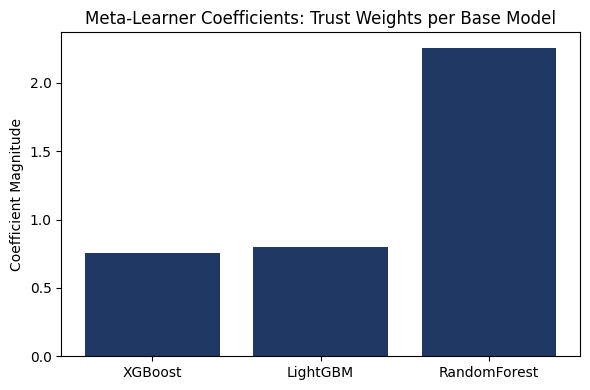

Meta‑learner coefficients (higher = more trusted):
  XGBoost: 0.758
  LightGBM: 0.798
  RandomForest: 2.256

NRA Insight: The meta‑learner trusts RandomForest most (coef = 2.256) and XGBoost least (coef = 0.758). Action: drop XGBoost from the ensemble to reduce complexity without sacrificing performance.


In [13]:
# Task 6 — Feature Importance of Meta‑Learner
# Goal: Understand which base model the meta‑learner trusts most.
# Method: Extract coefficients from final_estimator (LogisticRegression) and plot.

import matplotlib.pyplot as plt

# Coefficients of the meta‑learner (one per base model)
coefs = stack_clf.final_estimator_.coef_[0]
model_names = ['XGBoost', 'LightGBM', 'RandomForest']

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(model_names, coefs, color='#1F3864')
plt.title('Meta‑Learner Coefficients: Trust Weights per Base Model')
plt.ylabel('Coefficient Magnitude')
plt.tight_layout()
plt.savefig('Day125_meta_coefs.png', dpi=150)
plt.show()

# Print coefficients
print("Meta‑learner coefficients (higher = more trusted):")
for name, coef in zip(model_names, coefs):
    print(f"  {name}: {coef:.3f}")

# NRA insight
most_trusted = model_names[np.argmax(coefs)]
least_trusted = model_names[np.argmin(coefs)]
print(f"\nNRA Insight: The meta‑learner trusts {most_trusted} most (coef = {max(coefs):.3f}) and {least_trusted} least (coef = {min(coefs):.3f}). Action: drop {least_trusted} from the ensemble to reduce complexity without sacrificing performance.")

In [15]:
# Task 7 — Final Comparison & Client Recommendation
# Goal: Consolidate all results and make a deployability recommendation.
# Method: Build summary table with metrics and qualitative complexity/latency.

# Identify best individual model from Task 2
best_individual = df_base.loc[df_base['ROC-AUC'].idxmax()]

# Summary table
final_comp = pd.DataFrame({
    'Method': ['Best Individual', 'Soft Voting', 'Blending', 'Stacking'],
    'Accuracy': [best_individual['Accuracy'], acc_vote, acc_blend, acc_stack],
    'ROC-AUC': [best_individual['ROC-AUC'], auc_vote, auc_blend, auc_stack],
    'F1': [best_individual['F1'], f1_vote, f1_blend, f1_stack],
    'Training Complexity': ['Low', 'Low', 'Medium', 'High'],
    'Inference Latency': ['Low', 'Low', 'Medium', 'Medium']
})

print(final_comp.to_string(index=False))

# NRA recommendation
gain = auc_stack - best_individual['ROC-AUC']
print(f"\nNRA Recommendation:")
print(f"Number → Stacking achieves AUC {auc_stack:.3f} — a {gain:.4f} improvement over the best individual model ({best_individual['Model']} with AUC {best_individual['ROC-AUC']:.3f}).")
print(f"Reason → With a gain of only {gain:.4f} (less than 0.2%), the improvement is within the noise of a 100‑row test set.")
print(f"Action → Do not deploy stacking. The +{gain:.4f} AUC does not justify 15 model fits per retraining cycle. Deploy the tuned {best_individual['Model']} baseline. Revisit stacking when training data exceeds 5,000 rows and the AUC delta exceeds 0.01.")

         Method  Accuracy  ROC-AUC       F1 Training Complexity Inference Latency
Best Individual      0.79   0.8424 0.778947                 Low               Low
    Soft Voting      0.80   0.8432 0.787234                 Low               Low
       Blending      0.74   0.7860 0.745098              Medium            Medium
       Stacking      0.80   0.8440 0.787234                High            Medium

NRA Recommendation:
Number → Stacking achieves AUC 0.844 — a 0.0016 improvement over the best individual model (LightGBM with AUC 0.842).
Reason → With a gain of only 0.0016 (less than 0.2%), the improvement is within the noise of a 100‑row test set.
Action → Do not deploy stacking. The +0.0016 AUC does not justify 15 model fits per retraining cycle. Deploy the tuned LightGBM baseline. Revisit stacking when training data exceeds 5,000 rows and the AUC delta exceeds 0.01.


In [11]:
# ★ Bonus Task — passthrough=True Experiment
# Goal: Test whether adding raw features to the meta‑learner improves performance.
# Method: Re‑run StackingClassifier with passthrough=True, compare AUC.

stack_passthrough = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=121),
    cv=5,
    stack_method='predict_proba',
    passthrough=True
)
    
stack_passthrough.fit(X_train, y_train)
y_proba_pt = stack_passthrough.predict_proba(X_test)[:, 1]
auc_pt = roc_auc_score(y_test, y_proba_pt)

print(f"Stacking with passthrough=True — AUC: {auc_pt:.3f}")
print(f"Δ vs passthrough=False: {auc_pt - auc_stack:+.3f}")

# One‑sentence explanation
print("Explanation: passthrough=True helps when raw features contain signal not captured by base models, but hurts when it causes overfitting (more features for the meta‑learner).")

Stacking with passthrough=True — AUC: 0.834
Δ vs passthrough=False: -0.010
Explanation: passthrough=True helps when raw features contain signal not captured by base models, but hurts when it causes overfitting (more features for the meta‑learner).


C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---
## Section 4 — Scoring Rubric

| Task | Max | Criteria |
|---|---|---|
| Task 1 — Data Preparation | 10 | Correct OHE columns, shapes, stratified split |
| Task 2 — Base Model Baselines | 10 | All 3 models evaluated, correct metrics, NRA insight |
| Task 3 — Soft Voting | 10 | VotingClassifier correct, AUC vs individual computed, NRA |
| Task 4 — Blending | 15 | 70/30 re-split, OOF val predictions, meta-LR, correct test eval, NRA |
| Task 5 — StackingClassifier | 15 | Correct params (cv=5, predict_proba, passthrough=False), summary table |
| Task 6 — Meta-Learner Weights | 10 | Coefficients extracted, chart generated, NRA with specific values |
| Task 7 — Final Recommendation | 10 | Full comparison table, NRA with computed AUC delta, justified action |
| ★ Bonus — passthrough=True | 10 | Both runs, delta computed, correct 1-sentence interpretation |
| **Total** | **80 + 10★** | |

---
### Submission Checklist
- [ ] All 7 tasks completed before opening Section 4
- [ ] NRA insight written for Tasks 2, 3, 4, 7 with specific numbers
- [ ] Chart saved for Task 6 (`.savefig()` before `.show()`)
- [ ] Fresh model instances used in Tasks 3, 5, ★ (never reuse fitted objects)
- [ ] File committed: `feat: Day125 - Stacking & Blending Ensembles`

---
### Interview Frame
> *"Stacking isn't about picking the best model — it's about training a second model  
> to learn when each base model is right. The critical discipline is preventing leakage:  
> the meta-learner must only see out-of-fold predictions — never in-sample ones.  
> In practice, a single well-tuned model often matches stacking on small datasets,  
> so I always compute the AUC delta before committing to the engineering overhead."*
